In [18]:
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

data = fetch_olivetti_faces()
images = data.images
labels = data.target

print("Total images:", images.shape[0])
print("Image dimensions:", images.shape[1], "x", images.shape[2])
print("Number of unique subjects:", len(set(labels)))

Total images: 400
Image dimensions: 64 x 64
Number of unique subjects: 40


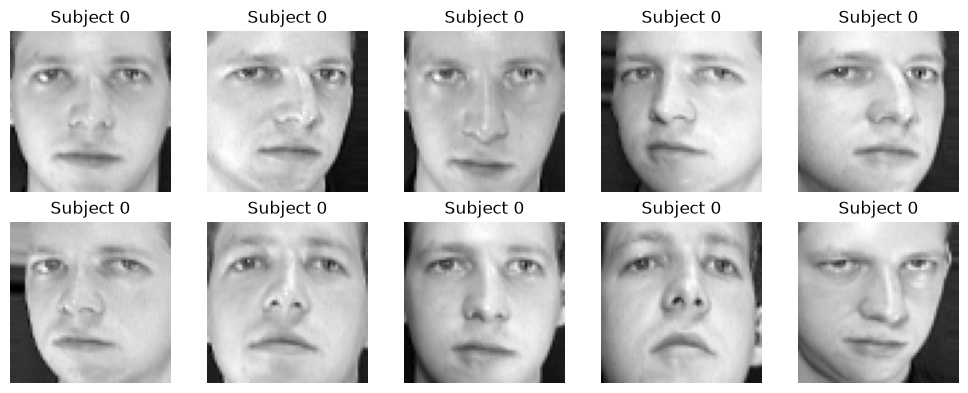

In [19]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i], cmap='gray')
    ax.set_title(f"Subject {labels[i]}")
    ax.axis('off')
plt.tight_layout()
plt.savefig("task1_sample_grid.png", dpi=150)
plt.show()

In [20]:
import numpy as np

enroll_images, enroll_labels = [], []
test_images, test_labels = [], []

for subject_id in np.unique(labels):
    idx = np.where(labels == subject_id)[0]
    enroll_images.extend(images[idx[:7]])
    enroll_labels.extend(labels[idx[:7]])
    test_images.extend(images[idx[7:]])
    test_labels.extend(labels[idx[7:]])

enroll_images = np.array(enroll_images)
test_images = np.array(test_images)

print("Enrollment set size:", len(enroll_images))
print("Test set size:", len(test_images))

Enrollment set size: 280
Test set size: 120


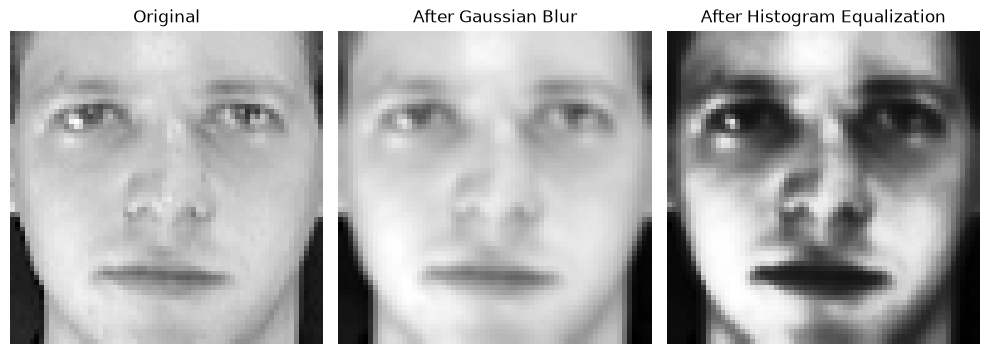

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def preprocess_image(img_float):
    img_uint8 = (img_float * 255).astype(np.uint8)      # normalize to 0-255
    denoised = cv2.GaussianBlur(img_uint8, (3, 3), 0)    # reduce noise
    enhanced = cv2.equalizeHist(denoised)                # fix lighting/contrast
    return enhanced

# apply to a single sample so we can see each stage separately
sample = images[0]
sample_uint8 = (sample * 255).astype(np.uint8)
sample_denoised = cv2.GaussianBlur(sample_uint8, (3, 3), 0)
sample_enhanced = cv2.equalizeHist(sample_denoised)

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
titles = ["Original", "After Gaussian Blur", "After Histogram Equalization"]
imgs = [sample_uint8, sample_denoised, sample_enhanced]

for ax, img, title in zip(axes, imgs, titles):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.savefig("task2_preprocessing_comparison.png", dpi=150)
plt.show()

In [22]:
enroll_processed = np.array([preprocess_image(img) for img in enroll_images])
test_processed = np.array([preprocess_image(img) for img in test_images])

print("Processed enrollment images:", enroll_processed.shape)
print("Processed test images:", test_processed.shape)

Processed enrollment images: (280, 64, 64)
Processed test images: (120, 64, 64)


Flattened enrollment shape: (280, 4096)


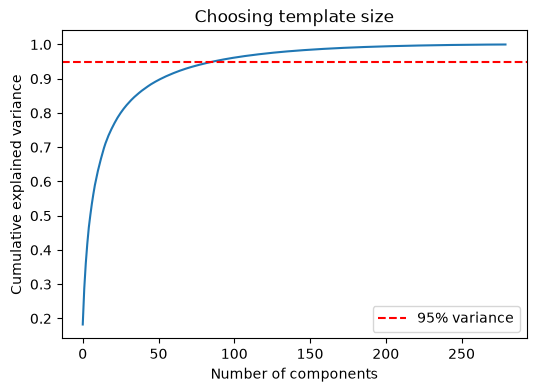

Components needed for 95% variance: 87


In [23]:
from sklearn.decomposition import PCA
import numpy as np

X_enroll = enroll_processed.reshape(enroll_processed.shape[0], -1)
X_test = test_processed.reshape(test_processed.shape[0], -1)
print("Flattened enrollment shape:", X_enroll.shape)

pca_full = PCA().fit(X_enroll)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(6, 4))
plt.plot(cumulative_variance)
plt.axhline(0.95, color='red', linestyle='--', label='95% variance')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("Choosing template size")
plt.legend()
plt.savefig("task3_pca_variance.png", dpi=150)
plt.show()

n_components = int(np.argmax(cumulative_variance >= 0.95) + 1)
print("Components needed for 95% variance:", n_components)

In [24]:
pca = PCA(n_components=n_components)
pca.fit(X_enroll)

enroll_templates = pca.transform(X_enroll)
test_templates = pca.transform(X_test)

print("Enrollment template shape:", enroll_templates.shape)
print("Test template shape:", test_templates.shape)

Enrollment template shape: (280, 87)
Test template shape: (120, 87)


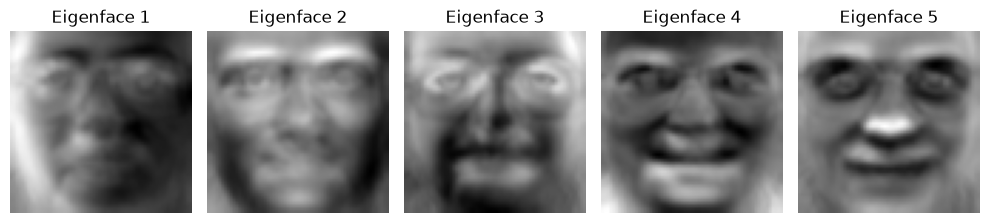

In [25]:
fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i, ax in enumerate(axes):
    eigenface = pca.components_[i].reshape(64, 64)
    ax.imshow(eigenface, cmap='gray')
    ax.set_title(f"Eigenface {i+1}")
    ax.axis('off')
plt.tight_layout()
plt.savefig("task3_eigenfaces.png", dpi=150)
plt.show()

In [26]:
raw_size = X_enroll[0].nbytes
template_size = enroll_templates[0].nbytes
print(f"Raw image size: {raw_size} bytes")
print(f"Template size: {template_size} bytes")
print(f"Compression ratio: {raw_size / template_size:.1f}x smaller")

Raw image size: 4096 bytes
Template size: 696 bytes
Compression ratio: 5.9x smaller


In [27]:
from sklearn.metrics.pairwise import euclidean_distances
import numpy as np

enroll_labels = np.array(enroll_labels)
test_labels = np.array(test_labels)

genuine_scores = []
impostor_scores = []

for i, test_vec in enumerate(test_templates):
    test_subject = test_labels[i]
    
    for j, enroll_vec in enumerate(enroll_templates):
        enroll_subject = enroll_labels[j]
        dist = np.linalg.norm(test_vec - enroll_vec)
        
        if test_subject == enroll_subject:
            genuine_scores.append(dist)
        else:
            impostor_scores.append(dist)

print(f"Genuine comparisons: {len(genuine_scores)}")
print(f"Impostor comparisons: {len(impostor_scores)}")
print(f"Genuine score mean: {np.mean(genuine_scores):.2f}")
print(f"Impostor score mean: {np.mean(impostor_scores):.2f}")

Genuine comparisons: 840
Impostor comparisons: 32760
Genuine score mean: 3167.81
Impostor score mean: 4722.90


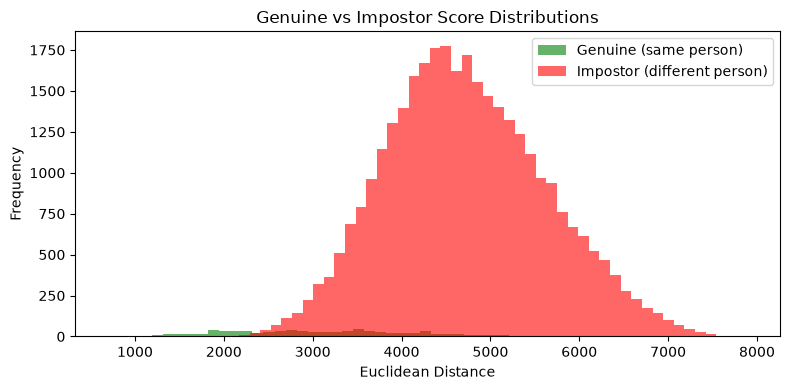

In [28]:
plt.figure(figsize=(8, 4))
plt.hist(genuine_scores, bins=50, alpha=0.6, color='green', label='Genuine (same person)')
plt.hist(impostor_scores, bins=50, alpha=0.6, color='red', label='Impostor (different person)')
plt.xlabel("Euclidean Distance")
plt.ylabel("Frequency")
plt.title("Genuine vs Impostor Score Distributions")
plt.legend()
plt.tight_layout()
plt.savefig("task4_score_distributions.png", dpi=150)
plt.show()

In [29]:
correct = 0
for i, test_vec in enumerate(test_templates):
    distances = [np.linalg.norm(test_vec - enroll_vec) for enroll_vec in enroll_templates]
    predicted_idx = np.argmin(distances)
    predicted_subject = enroll_labels[predicted_idx]
    
    if predicted_subject == test_labels[i]:
        correct += 1

accuracy = correct / len(test_templates) * 100
print(f"Identification accuracy (1:N): {correct}/{len(test_templates)} = {accuracy:.1f}%")

Identification accuracy (1:N): 103/120 = 85.8%


In [30]:
print(type(genuine_scores))
print(len(genuine_scores))
print(type(impostor_scores))
print(len(impostor_scores))

<class 'list'>
840
<class 'list'>
32760


In [31]:
import numpy as np

gs = np.array(genuine_scores)
ims = np.array(impostor_scores)

threshold = 3500

print(f"Threshold: {threshold}")
print(f"Genuine accepted (correct):   {np.sum(gs < threshold)}/{len(gs)}")
print(f"Genuine rejected (wrong):     {np.sum(gs >= threshold)}/{len(gs)}")
print(f"Impostors rejected (correct): {np.sum(ims >= threshold)}/{len(ims)}")
print(f"Impostors accepted (wrong):   {np.sum(ims < threshold)}/{len(ims)}")

Threshold: 3500
Genuine accepted (correct):   518/840
Genuine rejected (wrong):     322/840
Impostors rejected (correct): 30163/32760
Impostors accepted (wrong):   2597/32760


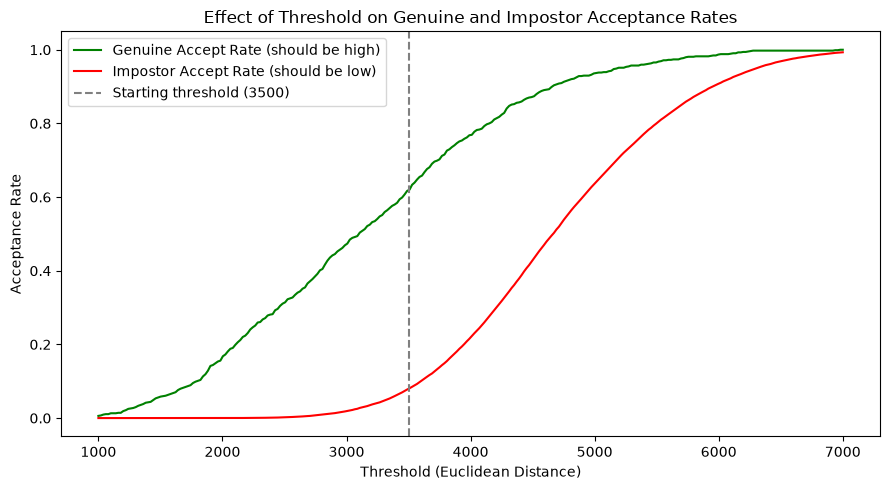

In [32]:
thresholds = np.linspace(1000, 7000, 300)

genuine_accept_rates = []
impostor_accept_rates = []

for t in thresholds:
    ga = np.sum(gs < t) / len(gs)
    ia = np.sum(ims < t) / len(ims)
    genuine_accept_rates.append(ga)
    impostor_accept_rates.append(ia)

plt.figure(figsize=(9, 5))
plt.plot(thresholds, genuine_accept_rates, color='green', label='Genuine Accept Rate (should be high)')
plt.plot(thresholds, impostor_accept_rates, color='red', label='Impostor Accept Rate (should be low)')
plt.axvline(x=3500, color='gray', linestyle='--', label='Starting threshold (3500)')
plt.xlabel("Threshold (Euclidean Distance)")
plt.ylabel("Acceptance Rate")
plt.title("Effect of Threshold on Genuine and Impostor Acceptance Rates")
plt.legend()
plt.tight_layout()
plt.savefig("task5_threshold_sweep.png", dpi=150)
plt.show()

In [33]:
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

gs = np.array(genuine_scores)
ims = np.array(impostor_scores)

# build ground truth labels and score array
# genuine = 1 (positive class), impostor = 0
# for ROC we need similarity not distance, so negate distances
all_scores = np.concatenate([-gs, -ims])
all_labels = np.concatenate([np.ones(len(gs)), np.zeros(len(ims))])

# FAR and FRR across thresholds
thresholds = np.linspace(1000, 7000, 1000)
FAR, FRR = [], []

for t in thresholds:
    far = np.sum(ims < t) / len(ims)
    frr = np.sum(gs >= t) / len(gs)
    FAR.append(far)
    FRR.append(frr)

FAR = np.array(FAR)
FRR = np.array(FRR)

# EER: point where FAR and FRR are closest
eer_idx = np.argmin(np.abs(FAR - FRR))
eer_threshold = thresholds[eer_idx]
eer_value = (FAR[eer_idx] + FRR[eer_idx]) / 2

print(f"EER threshold: {eer_threshold:.1f}")
print(f"FAR at EER:    {FAR[eer_idx]*100:.2f}%")
print(f"FRR at EER:    {FRR[eer_idx]*100:.2f}%")
print(f"EER:           {eer_value*100:.2f}%")

EER threshold: 4021.0
FAR at EER:    22.71%
FRR at EER:    22.98%
EER:           22.84%


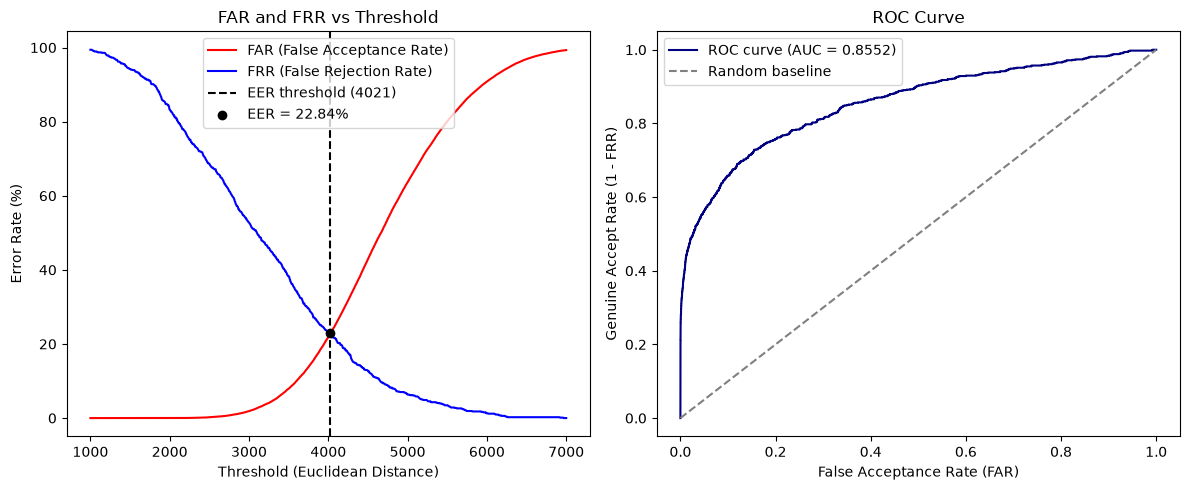

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: FAR and FRR vs threshold
axes[0].plot(thresholds, FAR*100, color='red', label='FAR (False Acceptance Rate)')
axes[0].plot(thresholds, FRR*100, color='blue', label='FRR (False Rejection Rate)')
axes[0].axvline(x=eer_threshold, color='black', linestyle='--', label=f'EER threshold ({eer_threshold:.0f})')
axes[0].scatter([eer_threshold], [eer_value*100], color='black', zorder=5, label=f'EER = {eer_value*100:.2f}%')
axes[0].set_xlabel("Threshold (Euclidean Distance)")
axes[0].set_ylabel("Error Rate (%)")
axes[0].set_title("FAR and FRR vs Threshold")
axes[0].legend()

# Right: ROC curve
fpr, tpr, _ = roc_curve(all_labels, all_scores)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='navy', label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random baseline')
axes[1].set_xlabel("False Acceptance Rate (FAR)")
axes[1].set_ylabel("Genuine Accept Rate (1 - FRR)")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.savefig("task6_far_frr_roc.png", dpi=150)
plt.show()

In [35]:
from skimage.feature import local_binary_pattern
import numpy as np

def extract_lbp(img, radius=1, n_points=8):
    lbp = local_binary_pattern(img, n_points, radius, method='uniform')
    n_bins = n_points + 2
    hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins), density=True)
    return hist

enroll_lbp = np.array([extract_lbp(img) for img in enroll_processed])
test_lbp = np.array([extract_lbp(img) for img in test_processed])

print("LBP template shape:", enroll_lbp[0].shape)
print("PCA template shape:", enroll_templates[0].shape)

LBP template shape: (10,)
PCA template shape: (87,)


In [36]:
# compute LBP distances
lbp_genuine, lbp_impostor = [], []

for i, test_vec in enumerate(test_lbp):
    for j, enroll_vec in enumerate(enroll_lbp):
        dist = np.linalg.norm(test_vec - enroll_vec)
        if test_labels[i] == enroll_labels[j]:
            lbp_genuine.append(dist)
        else:
            lbp_impostor.append(dist)

lbp_genuine = np.array(lbp_genuine)
lbp_impostor = np.array(lbp_impostor)

print(f"LBP genuine mean:   {np.mean(lbp_genuine):.4f}")
print(f"LBP impostor mean:  {np.mean(lbp_impostor):.4f}")

# min-max normalise both modalities into [0,1]
def normalise(scores, all_scores):
    mn, mx = all_scores.min(), all_scores.max()
    return (scores - mn) / (mx - mn)

pca_all = np.concatenate([gs, ims])
lbp_all = np.concatenate([lbp_genuine, lbp_impostor])

pca_gen_n = normalise(gs, pca_all)
pca_imp_n = normalise(ims, pca_all)
lbp_gen_n = normalise(lbp_genuine, lbp_all)
lbp_imp_n = normalise(lbp_impostor, lbp_all)

# sum fusion
fused_genuine  = pca_gen_n + lbp_gen_n
fused_impostor = pca_imp_n + lbp_imp_n

print(f"Fused genuine mean:  {np.mean(fused_genuine):.4f}")
print(f"Fused impostor mean: {np.mean(fused_impostor):.4f}")

LBP genuine mean:   0.0324
LBP impostor mean:  0.0590
Fused genuine mean:  0.4569
Fused impostor mean: 0.7817


PCA EER:    22.87%
LBP EER:    27.39%
Fused EER:  21.35%


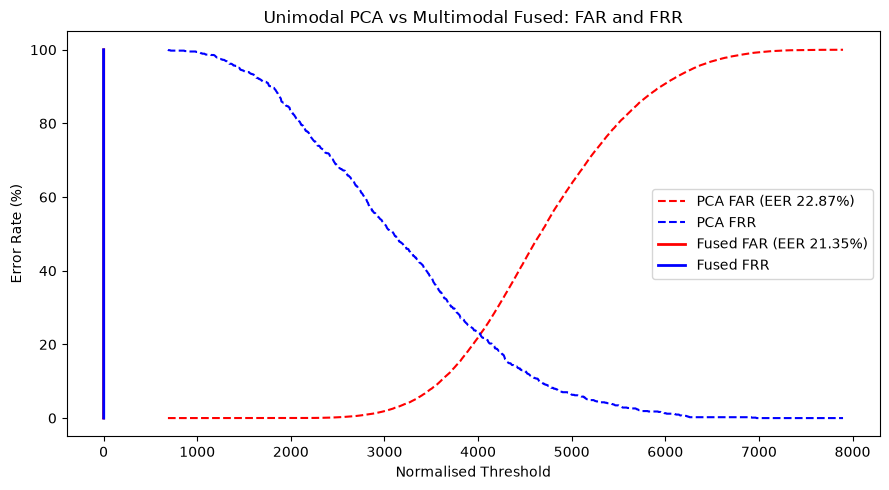

In [37]:
def compute_eer(genuine, impostor, steps=1000):
    mn = min(genuine.min(), impostor.min())
    mx = max(genuine.max(), impostor.max())
    thresholds = np.linspace(mn, mx, steps)
    FAR, FRR = [], []
    for t in thresholds:
        FAR.append(np.sum(impostor < t) / len(impostor))
        FRR.append(np.sum(genuine >= t) / len(genuine))
    FAR, FRR = np.array(FAR), np.array(FRR)
    idx = np.argmin(np.abs(FAR - FRR))
    eer = (FAR[idx] + FRR[idx]) / 2
    return eer * 100, thresholds[idx], FAR, FRR, thresholds

pca_eer, pca_t, pca_far, pca_frr, pca_thresh = compute_eer(gs, ims)
lbp_eer, lbp_t, lbp_far, lbp_frr, lbp_thresh = compute_eer(lbp_genuine, lbp_impostor)
fus_eer, fus_t, fus_far, fus_frr, fus_thresh = compute_eer(fused_genuine, fused_impostor)

print(f"PCA EER:    {pca_eer:.2f}%")
print(f"LBP EER:    {lbp_eer:.2f}%")
print(f"Fused EER:  {fus_eer:.2f}%")

plt.figure(figsize=(9, 5))
plt.plot(pca_thresh, pca_far*100, 'r--', label=f'PCA FAR (EER {pca_eer:.2f}%)')
plt.plot(pca_thresh, pca_frr*100, 'b--', label=f'PCA FRR')
plt.plot(fus_thresh, fus_far*100, 'r-',  label=f'Fused FAR (EER {fus_eer:.2f}%)', linewidth=2)
plt.plot(fus_thresh, fus_frr*100, 'b-',  label=f'Fused FRR', linewidth=2)
plt.xlabel("Normalised Threshold")
plt.ylabel("Error Rate (%)")
plt.title("Unimodal PCA vs Multimodal Fused: FAR and FRR")
plt.legend()
plt.tight_layout()
plt.savefig("task7_multimodal_comparison.png", dpi=150)
plt.show()